# Paper Figures

This notebook aims to reproduce the figures from/used in the paper.

In [64]:
import numpy as np

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [65]:
from diet4cola.advection import *
from diet4cola.cortex import *
from diet4cola.cut import *
from diet4cola.mask import *
from diet4cola.noise import *
from diet4cola.operations import *
from diet4cola.sdf import *
from diet4cola.utils import *

In [66]:
seed = 10
width = 512
height = 512

## Synthetic Cells

### Generation

In [67]:
fractal_n = fractal_snoise(get_snoise_generator(seed), width, height, 0.005, 1)
worley_n = worley_noise(width, height, 256, seed)

In [68]:
np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = cell_mask(width, height, (off_x, off_y), (200, 200), 50, seed)

In [69]:
#myosin_layer = myosin_noise(width, height, seed = seed, iterations=10)
#myosin_layer = mul(myosin_layer, cell_mask_layer)

In [70]:
#actin_layer = actin_noise(width, height, cell_mask_layer, 2560, -0.05, seed)
#actin_layer = mul(actin_layer, cell_mask_layer)

In [71]:
#actomyosin_layer = add(myosin_layer, actin_layer)
#actomyosin_layer = normalize(actomyosin_layer)

In [72]:
#save_cortex(actomyosin_layer, './data/cortex_2.npy')

In [73]:
actomyosin_layer = load_array('./data/cortex_2.npy')

### Visualization

In [74]:
cmap = 'gray'

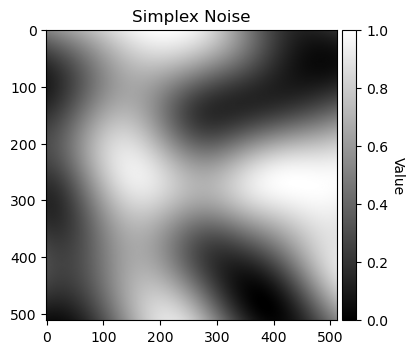

In [75]:
plot_2d_array(fractal_n, 'Simplex Noise', cmap)

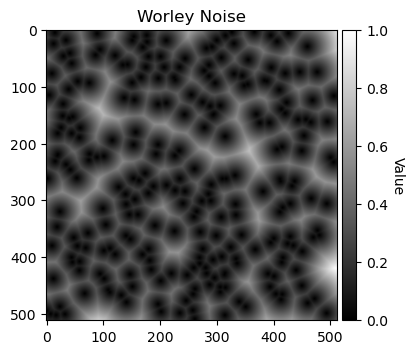

In [76]:
plot_2d_array(worley_n, 'Worley Noise', cmap)

In [77]:
save_2d_array(fractal_n, './data/simplex_example.png', cmap)
save_2d_array(worley_n, './data/worley_example.png', cmap)

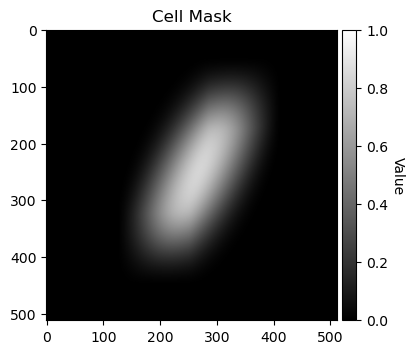

In [78]:
plot_2d_array(cell_mask_layer, 'Cell Mask', cmap)

In [79]:
save_2d_array(cell_mask_layer, './data/cell_mask_example.png', cmap)

In [80]:
#plot_2d_array(myosin_layer, 'Myosin', cmap)

In [81]:
#save_2d_array(myosin_layer, './data/myosin_example.png', cmap)

In [82]:
#plot_2d_array(actin_layer, 'Actin', cmap)

In [83]:
#save_2d_array(actin_layer, './data/actin_example.png', cmap)

In [84]:
#save_2d_array(invert(cell_mask_layer), './data/cell_mask_inverted_example.png', cmap)

In [85]:
#save_2d_array(invert(myosin_layer), './data/myosin_inverted_example.png', cmap)
#save_2d_array(invert(actin_layer), './data/actin_inverted_example.png', cmap)

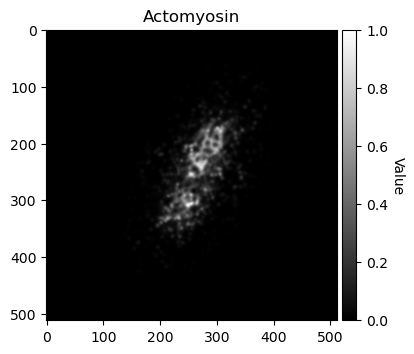

In [86]:
plot_2d_array(actomyosin_layer, 'Actomyosin', cmap)

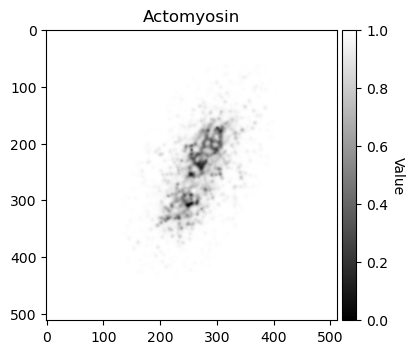

In [87]:
plot_2d_array(invert(actomyosin_layer), 'Actomyosin', cmap)

In [88]:
save_2d_array(actomyosin_layer, './data/actomyosin_example.png', cmap)
save_2d_array(invert(actomyosin_layer), './data/actomyosin_inverted_example.png', cmap)

## Synthetic Cut

In [89]:
from diet4cola.cut import *

def plot_synthetic_cut_crosses(data: np.ndarray,
                       cut_center: tuple[int, int],
                       cut_origin: tuple[int, int],
                       cut_destination: tuple[int, int],
                       filename: str,
                       cmap: str = 'gray',
                       min: float = 0,
                       max: float = 1) -> None:
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(np.ones((data.shape)), cmap=cmap, vmin=min, vmax=max)
    ax.set_title('Synthetic Cut')
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)  # pass the AxesImage, not the array
    cbar.set_label('Value', rotation=270, labelpad=12)

    ax.plot(
        [cut_origin[0], cut_destination[0]], 
        [cut_origin[1], cut_destination[1]], 
        color='black', linewidth=1, label='Cut', zorder=1, linestyle='--'
    )
    
    ax.scatter(cut_origin[0], cut_origin[1], color='Red', s=40, marker='x', label='Cut Origin', zorder=2)
    ax.scatter(cut_destination[0], cut_destination[1], color='blue', s=40, marker='x', label='Cut Destination', zorder=2)
    
    ax.legend(loc='upper right', fontsize=8)
    
    if filename:
        # Remove axes, colorbar, and title
        ax.set_axis_off()
        ax.set_title('')
        # Remove colorbar if it exists
        for c in fig.axes:
            if c is not ax:
                fig.delaxes(c)
        plt.margins(0)
        ax.set_position([0, 0, 1, 1])
        plt.savefig(filename, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    else:
        # Keep axes, title, and colorbar for interactive display
        ax.set_title('Synthetic Cut')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Value', rotation=270, labelpad=12)
        plt.show()

In [90]:
cola_cut = CoLACut((off_x, off_y), 32, 150, 200, seed + 1)

plot_synthetic_cut_crosses(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination, './data/cut_example', cmap=cmap)

## Velocity Field

In [91]:
from diet4cola.sdf import *

In [92]:
from matplotlib import patheffects

def save_sdf_array(data: np.ndarray, filename: str, cmap: str = 'gray', levels: list[float] = [0]) -> None:
    fig, ax = plt.subplots()

    im = ax.imshow(data, cmap=cmap, aspect='equal', interpolation='nearest')

    # Overlay contour lines
    if levels is not None:
        cs = ax.contour(data, levels=levels, colors='white', linewidths=1.0)

        # Label contours with distance values
        clabels = ax.clabel(
            cs,
            fmt=lambda x: f"{x:.2f}",   # format contour labels
            inline=True,               # keep labels off the lines
            fontsize=9,
            colors='white',
        )

        # Add outline (path effect) for better visibility
        for txt in clabels:
            txt.set_path_effects([
                patheffects.Stroke(linewidth=1.5, foreground='black', alpha=0.7),
                patheffects.Normal()
            ])

    # Remove borders, axes, margins
    ax.axis('off')
    plt.margins(0)
    ax.set_position([0, 0, 1, 1])  # fill entire figure

    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

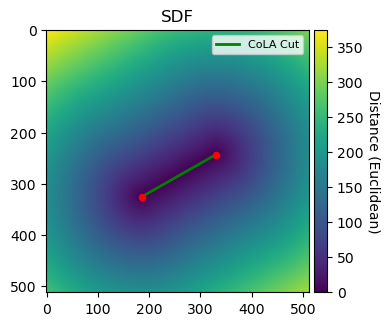

In [122]:
cut_sdf = compute_sdf(width, height, cola_cut.cut_origin, cola_cut.cut_destination, 0, True, sdf_segment)
plot_sdf(cut_sdf, cola_cut.cut_origin, cola_cut.cut_destination, cmap='viridis')

In [123]:
save_sdf_array(cut_sdf, './data/cut_sdf_example.png', 'viridis')

In [124]:
#cut_new = FixedCoLACut((256, 225), 100, 135)

def initialize_velocity_exponential(alpha: float, t: float, k: float) -> float:
    return alpha * np.exp(-t * k)

t_min = 0.0
t_max = 10.0  # Total simulation time (in seconds)
time_step = 1.0
timepoints = np.arange(t_min, t_max + time_step, time_step)
iterations = len(timepoints)

v_0 = 5
k = 0.25
initial_velocities = np.array([initialize_velocity_exponential(v_0, t, k) for t in timepoints])

print(initial_velocities)

WIDTH = 512
HEIGHT = 512

radii = [0] * iterations
widths = [0] * iterations

for i in range(iterations):
        if i == 0:
            radii[i] = 0
            widths[i] = 0
            continue

        #radii[i] = inverted_initial_velocities_normalized[i] * sdf_radius
        widths[i] = widths[i - 1] + time_step * initial_velocities[i]

[5.         3.89400392 3.0326533  2.36183276 1.83939721 1.43252398
 1.1156508  0.86886972 0.67667642 0.52699612 0.41042499]


In [125]:
from diet4cola.velocity import *

In [126]:
WIDTH = 512
HEIGHT = 512

falloff_distance = 100

# 5. Compute SDF and Velocity Fields
# 5a. Compute SDF fields
sdf_fields = compute_rounded_sdfs(WIDTH, HEIGHT, cola_cut.cut_origin, cola_cut.cut_destination, widths, radii, False, sdf_box, iterations)

# 5b. Create SDF Masks and Clipped SDF
masked_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, 1) for sdf in sdf_fields]) 
clipped_rounded_sdf_fields = np.array([mask_on_condition(sdf < 0, 0, sdf) for sdf in sdf_fields])

# 5c. Compute raw velocity fields
velocity_fields = compute_velocity_fields(clipped_rounded_sdf_fields, prior_exp, timepoints, initial_velocities, falloff_distance, iterations)

# 5d. Create masked velocity fields and zero out first timestep
masked_velocity_fields = np.array([vf * msdf for (vf, msdf) in zip(velocity_fields, masked_sdf_fields)])
masked_velocity_fields[0, :, :] = np.where(clipped_rounded_sdf_fields[0, :, :] < 1, masked_velocity_fields[0, :, :], 0)

# 5f. Compute SDF gradients
sdf_gradients = directional_gradients(clipped_rounded_sdf_fields)
sdf_dys = sdf_gradients[:, 0, :, :]
sdf_dxs = sdf_gradients[:, 1, :, :]

# 5g. Normalize the SDF gradients, s.t. we can infer velocity in dx and dy directions
grad_mag = np.sqrt(sdf_dxs ** 2 + sdf_dys ** 2 + 1e-8)
norm_dxs = sdf_dxs / grad_mag
norm_dys = sdf_dys / grad_mag

# 5h. Compute velocity components vel_dxs and vel_dys
vel_dxs = norm_dxs * velocity_fields
vel_dys = norm_dys * velocity_fields

# 5i. Compute blurred SDF fields 
blurred_masked_sdf_fields = np.array([blur(sdf.astype(np.float64), (5, 5), 5) for sdf in masked_sdf_fields])

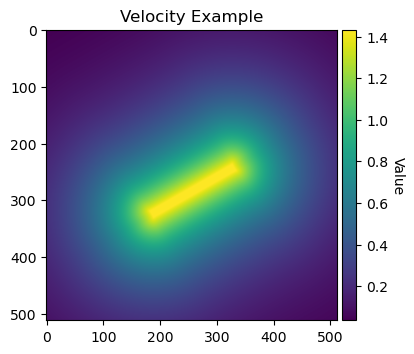

In [127]:
i=5
plot_2d_array(velocity_fields[i], 'Velocity Example', 'viridis', np.min(velocity_fields[i]), np.max(velocity_fields[i]))

In [128]:
save_2d_array(velocity_fields[i], './data/velocity_example.png', 'viridis')

In [129]:
# 5f. Compute SDF gradients
sdf_gradients = directional_gradients(clipped_rounded_sdf_fields)
sdf_dys = sdf_gradients[:, 0, :, :]
sdf_dxs = sdf_gradients[:, 1, :, :]

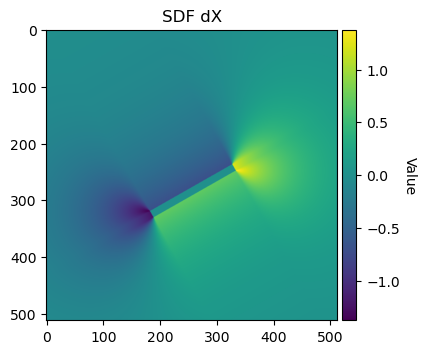

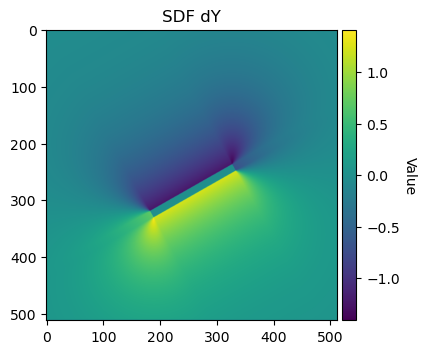

In [130]:
v_x = sdf_dxs[i] * masked_velocity_fields[i]
v_y = sdf_dys[i] * masked_velocity_fields[i]

plot_2d_array(v_x, 'SDF dX', 'viridis', np.min(v_x), np.max(v_x))
plot_2d_array(v_y, 'SDF dY', 'viridis', np.min(v_y), np.max(v_y))

In [131]:
save_2d_array(v_x, './data/vel_dx.png', 'viridis')
save_2d_array(v_y, './data/vel_dy.png', 'viridis')

In [137]:
from diet4cola.model.models import *
from diet4cola.model.tracking import *

model = load_unet_model('../models/model_MwP9cKL3ADHzq9uUrr3HgH')

In [141]:
frames = advect_backward_sim(actomyosin_layer, sdf_dxs, sdf_dys, velocity_fields, iterations, time_step)

In [153]:
import torch

input = torch.tensor((frames[5], frames[6]), dtype=torch.float32).unsqueeze(0)
output = model(input)

velocity_field = output.squeeze(0).cpu().detach().numpy()
pvx = velocity_field[0]
pvy = velocity_field[1]

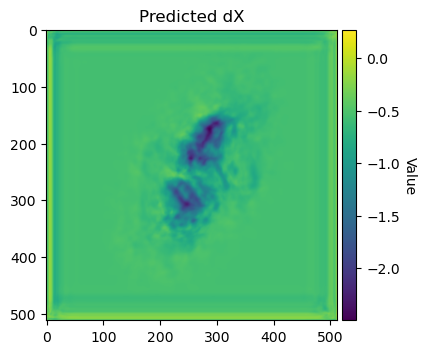

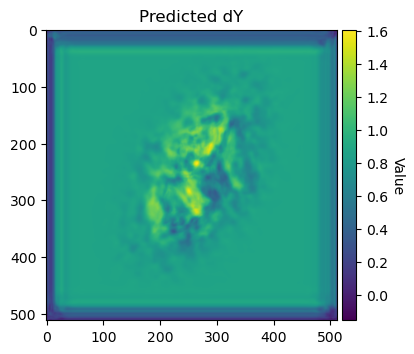

In [156]:
plot_2d_array(pvx, 'Predicted dX', 'viridis', np.min(pvx), np.max(pvx))
plot_2d_array(pvy, 'Predicted dY', 'viridis', np.min(pvy), np.max(pvy))

save_2d_array(pvx, './data/pred_vel_dx.png', 'viridis')
save_2d_array(pvy, './data/pred_vel_dy.png', 'viridis')